In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score
print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df=pd.read_csv("../../data/fifa_world_cup_2026_player_performance.csv")
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,match_id,match_date,stadium,city,opponent_team,tournament_stage,match_result,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.8,0.7,26.5,13,23,81.9,5.6,50.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.4,1.1,29.0,19,17,85.5,5.7,55.9,37.9,29.4,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.8,1.3,33.7,30,19,88.8,8.3,82.9,79.8,78.6,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,PSV Eindhoven,11805512,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,80,1,1,5,2,0.00,0.21,0,12,19,0.67,1,0,0,0,1,1,1,0,3,0,1,3,0,1,0,0,0,0,0.00,0,0,0,0,9.6,1.0,32.1,26,19,89.2,6.9,67.5,47.3,6.9,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,79,0,0,1,0,0.00,0.00,1,33,44,0.76,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.00,0,0,0,0,7.5,0.7,30.5,23,18,73.6,5.7,55.4,33.0,75.6,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [3]:
print("Shape:",df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Shape: (54600, 75)

Columns:
['player_id', 'player_name', 'age', 'nationality', 'team', 'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot', 'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium', 'city', 'opponent_team', 'tournament_stage', 'match_result', 'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy', 'dribbles_attempted', 'successful_dribbles', 'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances', 'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries', 'defensive_actions', 'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves', 'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'decelerations', 'stamina_score', 'player_rati

In [4]:
missing_values=df.isnull().sum()
print(missing_values)

player_id                   0
player_name                 0
age                         0
nationality                 0
team                        0
                           ..
total_goals_tournament      0
total_assists_tournament    0
total_minutes_tournament    0
player_of_match_awards      0
tournament_rating           0
Length: 75, dtype: int64


In [5]:
before=len(df); df=df.drop_duplicates().copy(); after=len(df)
print("Rows before removing duplicates:",before)
print("Rows after removing duplicates:",after)
print("Duplicate rows removed:",before-after)

Rows before removing duplicates: 54600
Rows after removing duplicates: 54600
Duplicate rows removed: 0


In [6]:
df["match_date"]=pd.to_datetime(df["match_date"],errors="coerce")
features=["age","minutes_played","shots","shots_on_target","key_passes","successful_passes","tackles","interceptions","distance_covered_km","top_speed_kmh"]
target="player_rating"
for col in features+[target]: df[col]=pd.to_numeric(df[col],errors="coerce")
df=df.dropna(subset=features+[target]).copy()
print("Selected features:",features)
print("Target:",target)
print("Prepared dataset shape:",df.shape)

Selected features: ['age', 'minutes_played', 'shots', 'shots_on_target', 'key_passes', 'successful_passes', 'tackles', 'interceptions', 'distance_covered_km', 'top_speed_kmh']
Target: player_rating
Prepared dataset shape: (54600, 75)


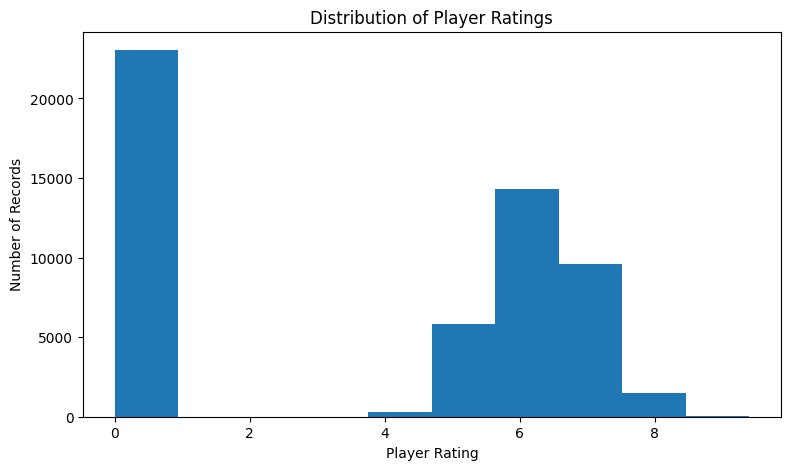

In [7]:
plt.figure(figsize=(9,5)); plt.hist(df[target],bins=10); plt.title("Distribution of Player Ratings"); plt.xlabel("Player Rating"); plt.ylabel("Number of Records"); plt.show()

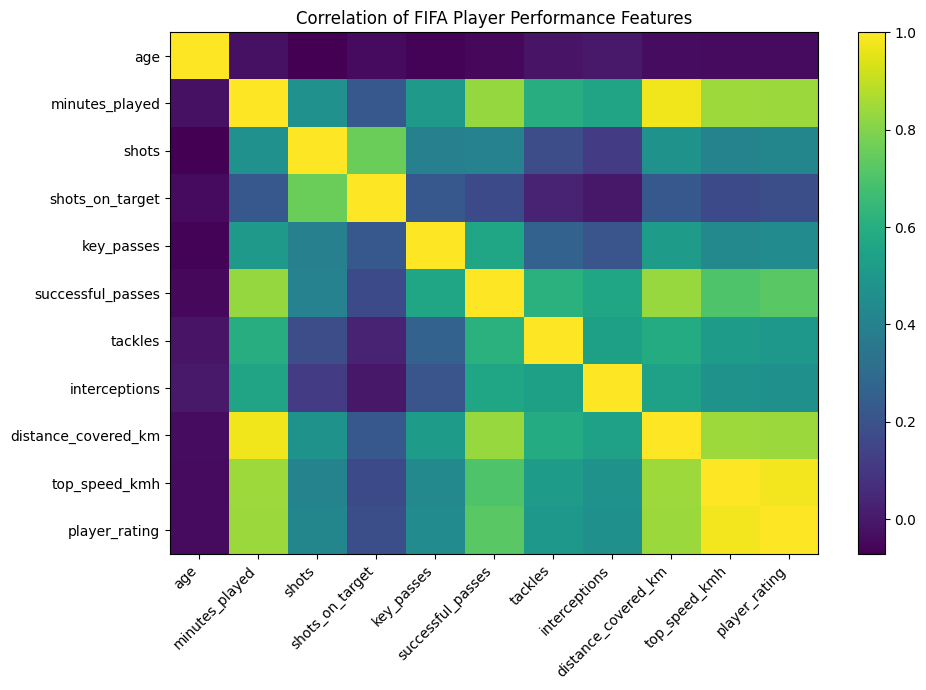

In [8]:
corr=df[features+[target]].corr()
plt.figure(figsize=(10,7)); plt.imshow(corr,aspect="auto"); plt.colorbar(); plt.xticks(range(len(corr.columns)),corr.columns,rotation=45,ha="right"); plt.yticks(range(len(corr.columns)),corr.columns); plt.title("Correlation of FIFA Player Performance Features"); plt.tight_layout(); plt.show()

In [9]:
X=df[features]; y=df[target]
print("Input shape:",X.shape)
print("Target shape:",y.shape)
print("\nFirst 5 input records:"); display(X.head())
print("\nFirst 5 target values:"); display(y.head())

Input shape: (54600, 10)
Target shape: (54600,)

First 5 input records:


,age,minutes_played,shots,shots_on_target,key_passes,successful_passes,tackles,interceptions,distance_covered_km,top_speed_kmh
0,26,72,0,0,0,15,0,0,7.8,26.5
1,19,90,0,0,1,35,0,1,10.4,29.0
2,18,73,2,0,2,72,1,1,8.8,33.7
3,20,80,5,2,0,12,1,1,9.6,32.1
4,23,79,1,0,1,33,1,3,7.5,30.5



First 5 target values:


0    5.6
1    5.7
2    8.3
3    6.9
4    5.7
Name: player_rating, dtype: float64

In [10]:
sample_size=min(50000,len(df)); model_df=df.sample(n=sample_size,random_state=42)
X=model_df[features]; y=model_df[target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Training records:",len(X_train)); print("Testing records:",len(X_test))

Training records: 40000
Testing records: 10000


In [11]:
model=RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1); model.fit(X_train,y_train); print("Random Forest model trained successfully")

Random Forest model trained successfully


In [12]:
y_pred=model.predict(X_test)
comparison=pd.DataFrame({"Actual Rating":y_test.to_numpy()[:15],"Predicted Rating":np.round(y_pred[:15],2)})
comparison

,Actual Rating,Predicted Rating
0,7.2,6.48
1,6.3,6.28
2,6.7,6.29
3,7.0,7.14
4,0.0,0.00
5,0.0,0.00
6,5.9,6.16
7,5.4,6.47
8,0.0,0.00
9,6.1,6.15


In [13]:
mae=mean_absolute_error(y_test,y_pred); r2=r2_score(y_test,y_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.3243
R² Score: 0.9714


In [14]:
importance=pd.DataFrame({"Feature":features,"Importance":model.feature_importances_}).sort_values("Importance",ascending=False)
importance

,Feature,Importance
9,top_speed_kmh,0.383536
1,minutes_played,0.353241
8,distance_covered_km,0.246716
5,successful_passes,0.006442
0,age,0.003964
6,tackles,0.001641
7,interceptions,0.001484
2,shots,0.001429
4,key_passes,0.001423
3,shots_on_target,0.000125
